In [ ]:
%load_ext autoreload
%autoreload 2


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torchvision
from torch import nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau,MultiStepLR, CyclicLR, LambdaLR
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler,TensorDataset
import torchvision.datasets as datasets
from torchvision.transforms.v2 import Compose, Normalize,Resize,ToImage,ToDtype,CenterCrop

from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
from torchinfo import summary
from torch.hub import load_state_dict_from_url

from torchvision.models import alexnet, resnet18, inception_v3


from sklearn.metrics import f1_score, confusion_matrix, classification_report

from utils.train import StepByStep
from utils.overfit_single_batch import overfit_single_batch
from generate_primitive_shapes import generate_shape_dataset
from utils.calculate_img_statistics import calculate_statistics


#poetry run tensorboard --logdir runs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate Dataset


In [119]:
# generate_shape_dataset(base_dir="dataset/train/",samples_per_class=800, img_size=64)
# generate_shape_dataset(base_dir="dataset/test/",samples_per_class=200, img_size=64)

In [120]:
#generate_shape_dataset(base_dir="shape_dataset",samples_per_class=1000, img_size=64)
# generator = torch.Generator().manual_seed(42)
# Img_Stat=calculate_statistics('/dataset/train/',batch_size=64)


# composer=Compose([ToImage(),
#                   ToDtype(torch.float32, scale=True),
#                   Normalize(mean=Img_Stat["Mean"],std=Img_Stat["Std"])])

# train_dataset=datasets.ImageFolder('dataset/train',transform=composer)
# val_dataset=datasets.ImageFolder('dataset/train',transform=composer)

# batch_size=64
# train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
# val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)




torch.manual_seed(17)

normalizer = Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])

composer = Compose([Resize(256),
                    CenterCrop(224),
                    ToImage(), 
                    ToDtype(torch.float32, scale=True),
                    normalizer])

train_data = ImageFolder(root='dataset/train/', transform=composer)
val_data = ImageFolder(root='dataset/test/', transform=composer)

# Builds a loader of each set
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


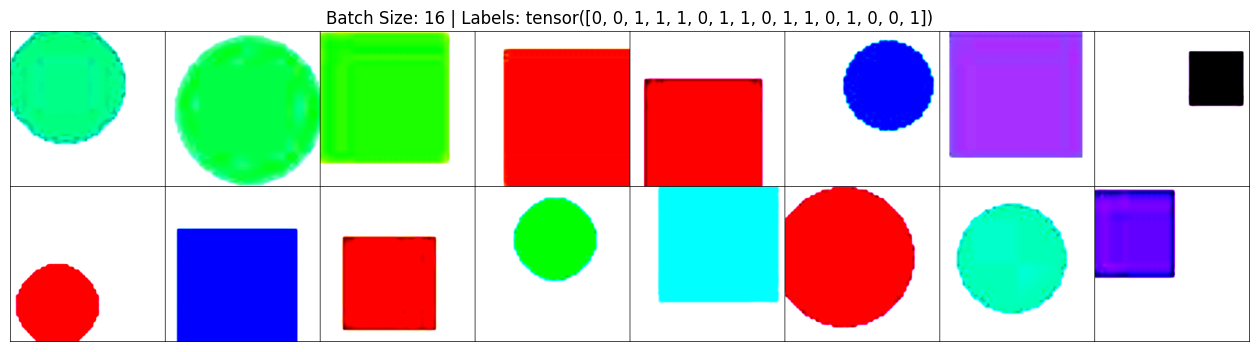

In [121]:
# Vizualise single batch

batch,labels=next(iter(train_loader))
grid = torchvision.utils.make_grid(batch, nrow=8, padding=1)

# 4. PyTorch uses (Channels, Height, Width), but Matplotlib requires (Height, Width, Channels)
grid_np = grid.permute(1, 2, 0).numpy()

# 5. Plot the grid
plt.figure(figsize=(16, 8))
plt.imshow(grid_np)
plt.axis('off') # Hide axes for a cleaner look
plt.title(f"Batch Size: {batch.size(0)} | Labels: {labels}")
plt.show()


## AlexNet

In [ ]:
from torchvision.models.alexnet import AlexNet_Weights
##################################################################
### Data preparation
torch.manual_seed(17)

normalizer = Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])

composer = Compose([Resize(256),
                    CenterCrop(224),
                    ToImage(), 
                    ToDtype(torch.float32, scale=True),
                    normalizer])

train_data = ImageFolder(root='dataset/train/', transform=composer)
val_data = ImageFolder(root='dataset/test/', transform=composer)

# Builds a loader of each set
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)


##################################################################
### Load model
alex=alexnet(weights=None)
#summary(alex)

weights=AlexNet_Weights.DEFAULT
url=weights.url
state_dict=load_state_dict_from_url(url,model_dir='pretrained',progress=True)
alex.load_state_dict(state_dict)


def freeze_model(model):
    for parameter in model.parameters():
        parameter.requires_grad=False

freeze_model(alex)

alex.classifier[6]=nn.Identity()


In [77]:
def preprocessed_dataset(model, loader, device=None):
    if device is None:
        device = next(model.parameters()).device
    
    features = None
    labels = None

    for i, (x, y) in enumerate(loader):
        model.eval()
        x = x.to(device)
        output = model(x)
        if i == 0:
            features = output.detach().cpu()
            labels = y.cpu()
        else:
            features = torch.cat([features, output.detach().cpu()])
            labels = torch.cat([labels, y.cpu()])

    dataset = TensorDataset(features, labels)
    return dataset


train_preproc = preprocessed_dataset(alex, train_loader)
val_preproc = preprocessed_dataset(alex, val_loader)

torch.save(train_preproc.tensors, 'rps_preproc.pth')
torch.save(val_preproc.tensors, 'rps_val_preproc.pth')


# Builds a loader of each set
train_loader = DataLoader(train_preproc, batch_size=16, shuffle=True)
val_loader = DataLoader(val_preproc, batch_size=16)

In [79]:
model=nn.Sequential(nn.Linear(4096,2))

multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_alex = optim.Adam(model.parameters(), lr=3e-4)
sbs_alex = StepByStep(model, multi_loss_fn, optimizer_alex)
sbs_alex.set_loaders(train_loader, val_loader)
sbs_alex.train(10)

Epoch [0/10] -> Train Loss: 0.0506 | Val Loss: 0.0057 | F1_ score: 1.0000
Epoch [1/10] -> Train Loss: 0.0047 | Val Loss: 0.0028 | F1_ score: 1.0000
Epoch [2/10] -> Train Loss: 0.0026 | Val Loss: 0.0017 | F1_ score: 1.0000
Epoch [3/10] -> Train Loss: 0.0017 | Val Loss: 0.0012 | F1_ score: 1.0000
Epoch [4/10] -> Train Loss: 0.0012 | Val Loss: 0.0009 | F1_ score: 1.0000
Epoch [5/10] -> Train Loss: 0.0009 | Val Loss: 0.0007 | F1_ score: 1.0000
Epoch [6/10] -> Train Loss: 0.0007 | Val Loss: 0.0006 | F1_ score: 1.0000
Epoch [7/10] -> Train Loss: 0.0006 | Val Loss: 0.0005 | F1_ score: 1.0000
Epoch [8/10] -> Train Loss: 0.0005 | Val Loss: 0.0004 | F1_ score: 1.0000
Epoch [9/10] -> Train Loss: 0.0004 | Val Loss: 0.0003 | F1_ score: 1.0000


In [80]:
alex.classifier[6]=model

# Inception_v3

In [126]:
torch.manual_seed(42)

normalizer = Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])

composer = Compose([Resize(299),
                    ToImage(), 
                    ToDtype(torch.float32, scale=True),
                    normalizer])

train_data = ImageFolder(root='dataset/train/', transform=composer)
val_data = ImageFolder(root='dataset/test/', transform=composer)

# Builds a loader of each set
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)



#################################################################
from torchvision.models.inception import Inception_V3_Weights


model_inception = inception_v3(weights=Inception_V3_Weights.DEFAULT)
freeze_model(model_inception)

model_inception.AuxLogits.fc = nn.Linear(768, 3)
model_inception.fc = nn.Linear(2048, 3)

def inception_loss(outputs, labels):
    try:
        main, aux = outputs
    except ValueError:
        main = outputs
        aux = None
        loss_aux = 0
        
    multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
    loss_main = multi_loss_fn(main, labels)
    if aux is not None:
        loss_aux = multi_loss_fn(aux, labels)
    return loss_main + 0.4 * loss_aux


optimizer_model_preception = optim.Adam(model_inception.parameters(), lr=3e-4)
sbs_incep = StepByStep(model_inception, inception_loss, optimizer_model_preception )
sbs_incep.set_loaders(train_loader,val_loader)

sbs_incep.train(1)

Epoch [0/1] -> Train Loss: 0.4810 | Val Loss: 0.1706 | F1_ score: 1.0000
